In [28]:
import openmc
import pyvista as pv
import stellarvista as sv

## Load DAGMC geometry

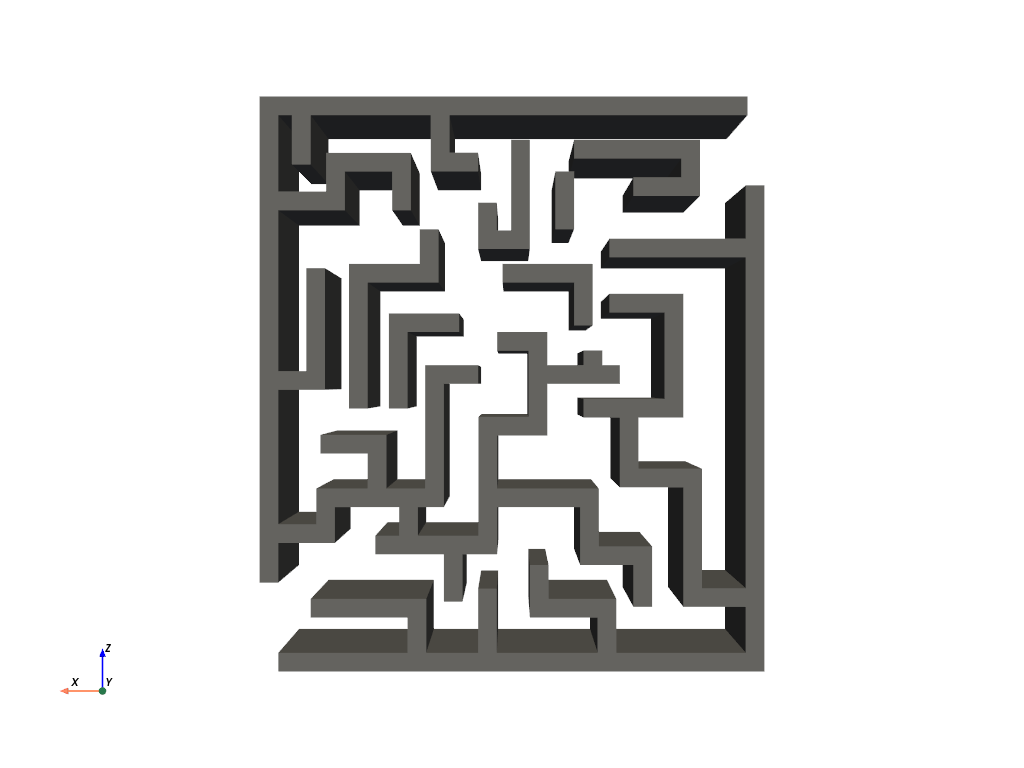

In [ ]:
maze = sv.import_dagmc('./model_labrynth/dagmc.h5m')
maze.plot(jupyter_backend='static', cpos=[0,1,0], color='gray')

## Load tally data and mesh

Here we open our tally from the statepoint file, convert it to a pandas dataframe, and locate the regular mesh used in the tally.

These two objects are then passed into stellarvista to create the pyvista objects.

Any columns present in the dataframe will be passed to pyvista, this is useful for adding **normalized tally data**.

StructuredGrid (0x7fce54158700)
  N Cells:      1000000
  N Points:     1030301
  X Bounds:     -2.681e+03, 2.721e+03
  Y Bounds:     -1.000e+00, 1.501e+03
  Z Bounds:     -3.014e+03, 3.138e+03
  Dimensions:   101, 101, 101
  N Arrays:     7

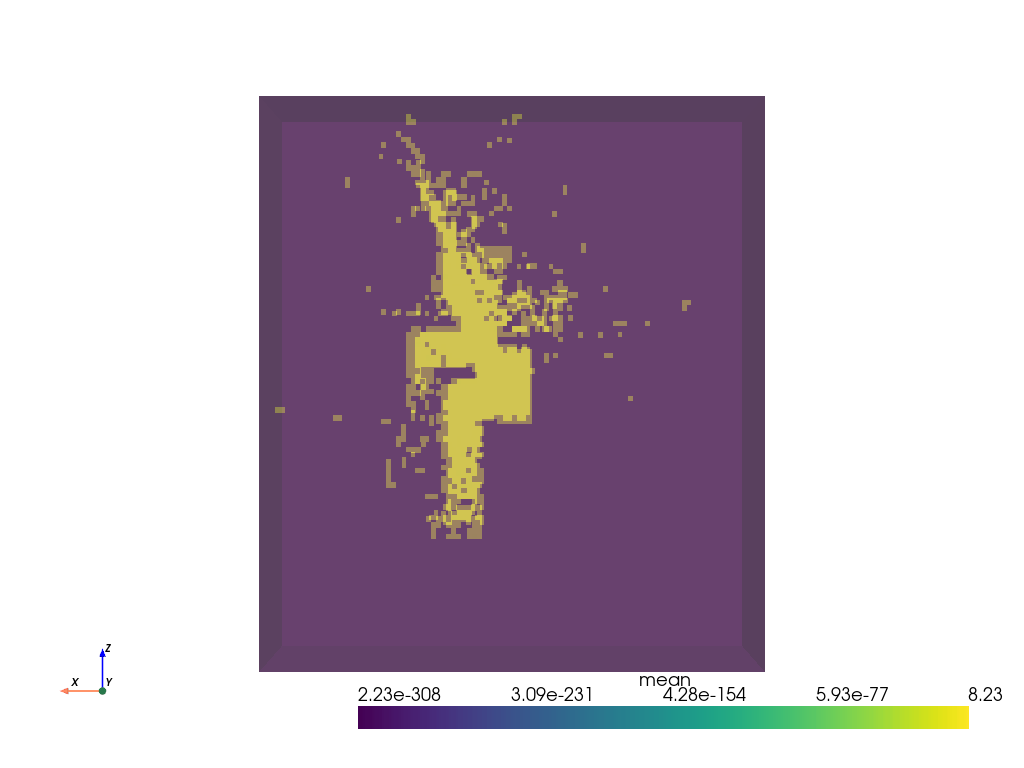

In [59]:
# import the tally and tally mesh from the statepoint file
with openmc.StatePoint('./model_labrynth/statepoint.10.h5') as sp:
    df = sp.get_tally(name='flux').get_pandas_dataframe()
    mesh = sp.get_tally(name='flux').find_filter(openmc.MeshFilter).mesh

# use stellarvista to create pyvista mesh objects
flux = sv.regular_mesh_tally_to_pv(mesh, df)
display(flux)
# plot the mean score
flux.plot(scalars='mean', log_scale=True, cmap='viridis', opacity=0.5, jupyter_backend='static', cpos=[0,1,0])

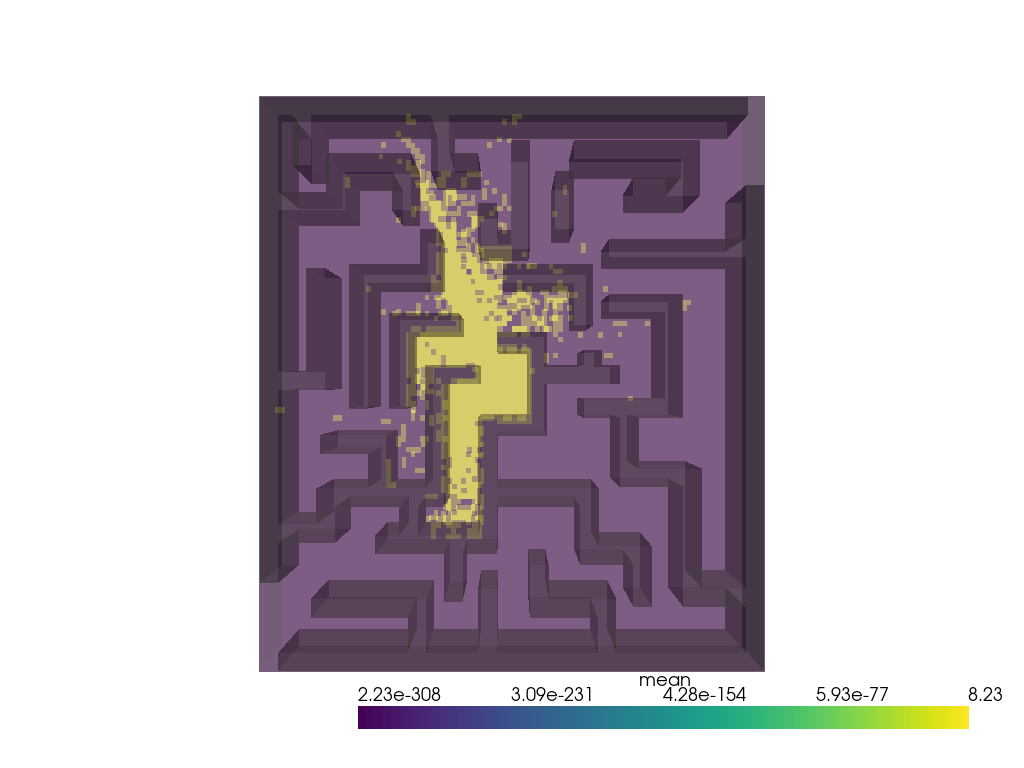

In [55]:
plot = pv.Plotter()
plot.add_mesh(maze, color='gray', opacity=0.5)
plot.add_mesh(flux, log_scale=True, opacity=0.4, scalars='mean')
plot.show(jupyter_backend='static', cpos=[0,1,0])

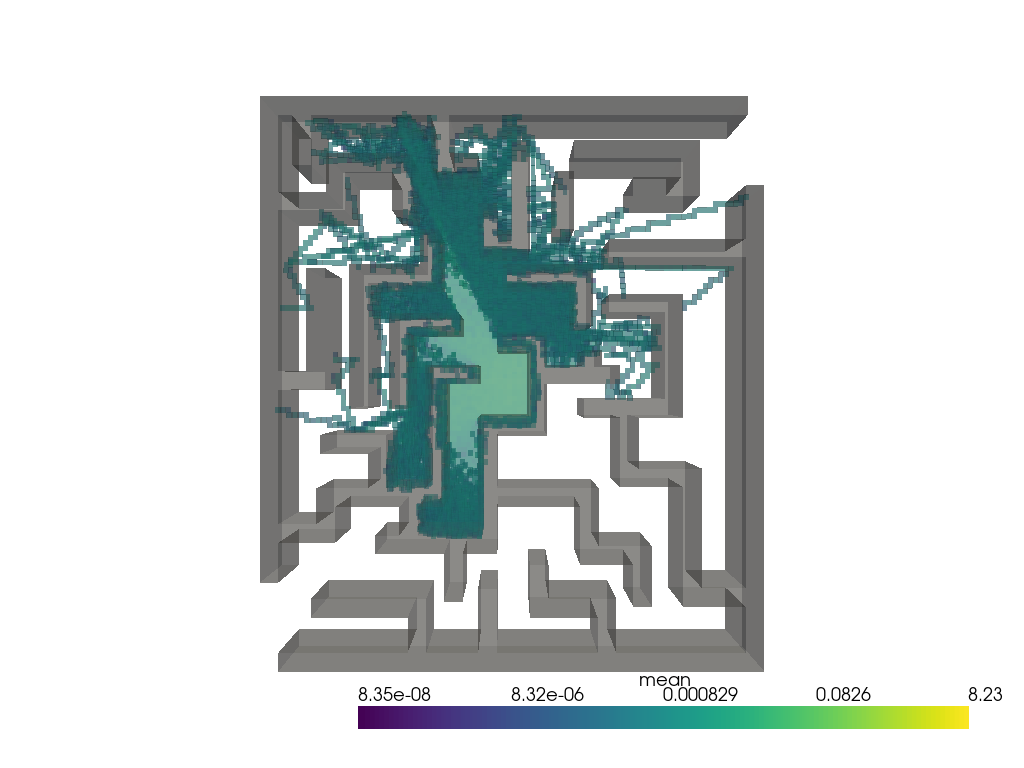

In [53]:
plot = pv.Plotter()
plot.add_mesh(maze, color='gray', opacity=0.5)
plot.add_mesh(flux.threshold(1e-9, scalars='mean'), log_scale=True, opacity=0.4, scalars='mean')
plot.show(jupyter_backend='static', cpos=[0,1,0])

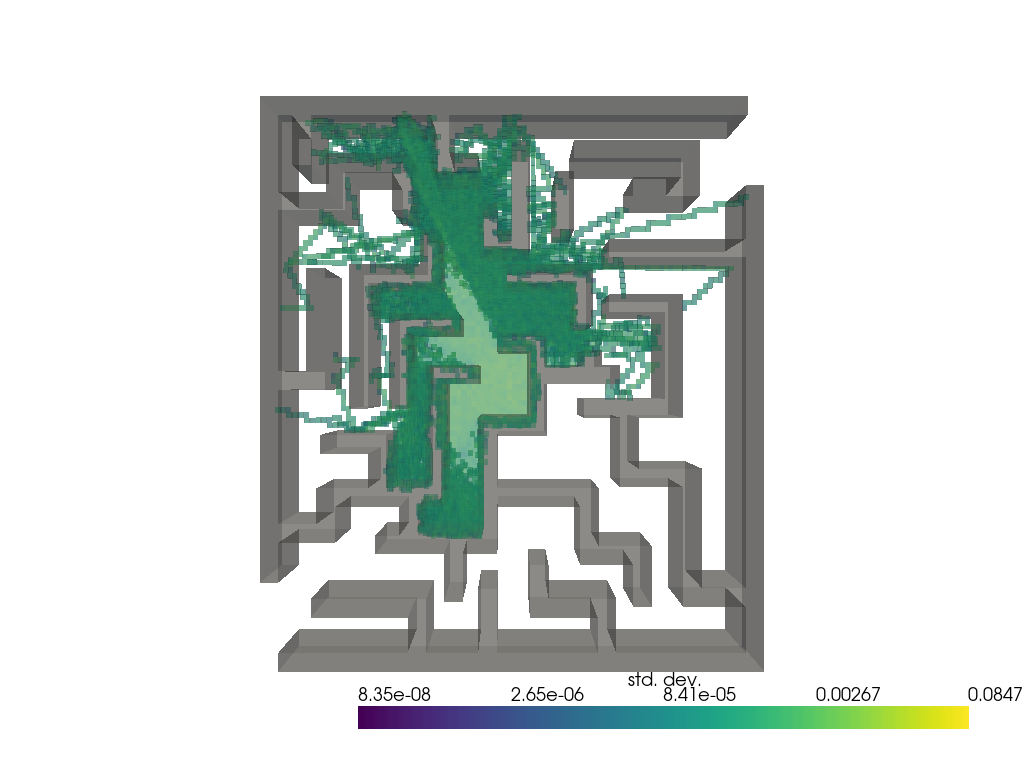

In [54]:
plot = pv.Plotter()
plot.add_mesh(maze, color='gray', opacity=0.5)
plot.add_mesh(flux.threshold(1e-9, scalars='std. dev.'), log_scale=True, opacity=0.4, scalars='std. dev.')
plot.show(jupyter_backend='static', cpos=[0,1,0])